# Sympy Test Sandbox
### This notebook is used to test various techniques used in typesetting the diagrams for this project.

In [1]:
import matplotlib.pyplot as plt
import math as m
import numpy as np  # 1.7 or higher
from ipywidgets import interactive
from IPython.display import display, Image
import PIL
from io import BytesIO


#from PIL import Image

import qgrid
import pandas as pd

import sympy as sym
sym.init_printing(order="none")
from sympy.vector import CoordSys3D
import sympy.vector as symvec

import scipy

np.set_printoptions(suppress=True, 
                    formatter={'float_kind':'{:14.4f}'.format})  
%matplotlib inline


def display_img_array(ima):
    im = PIL.Image.fromarray(ima)
    bio = BytesIO()
    im.save(bio, format='png')
    display(Image(bio.getvalue(), format='png'))

def display_image(path):
    pil_im = PIL.Image.open(path)
    display(pil_im)

In [2]:
# a list of links that were useful in getting sympy-generated 
# LaTeX'd PDFs into Affinity Designer.  Hint:  Install 
# Latin Modern fonts

# [click me](https://en.wikipedia.org)

# https://medium.com/analytics-vidhya/the-ultimate-markdown-guide-for-jupyter-notebook-d5e5abf728fd
# https://saturncloud.io/blog/how-to-use-latex-in-jupyter-notebook/
# https://docs.sympy.org/latest/tutorials/intro-tutorial/basic_operations.html
# https://tug.org/mactex/
# jupyter nbconvert --to pdf notebook.ipynb
# install Latin Modern OTF fonts for PDF editing in drawing programs
# https://www.gust.org.pl/projects/e-foundry/lm-math
# https://www.gust.org.pl/projects/e-foundry/latin-modern/download
# *** MIGRATING TO NOTEBOOK 7 nbextensions
# https://jupyter-notebook.readthedocs.io/en/latest/migrate_to_notebook7.html


<dl>
<dt>First Term</dt>
<dd>This is the definition of the first term.</dd>
<dt>Second Term</dt>
<dd>This is one definition of the second term. </dd>
<dd>This is another definition of the second term.</dd>
</dl>

In [3]:
# good sympy tutorial 
# https://dynamics-and-control.readthedocs.io/en/latest/0_Getting_Started/Notebook%20introduction.html

x = sym.Symbol('x')
x

In [4]:
# type \gamma<tab> to insert symbol
g = sym.Symbol('γ')
g

In [5]:
# https://docs.sympy.org/latest/modules/vector/
N = CoordSys3D('N')
N.i

In [6]:
v = 2*N.i + N.j
v

In [7]:
k = symvec.Cross(N.i, N.j)
k
#help(symvec.cross)

In [8]:
Vp, Vr = sym.symbols(r'\vec{V_p} \vec{V_r}')
abs(abs(Vr))

In [9]:
#for e in eqs:
#    print(sym.latex(e))

sym.latex(abs(Vr))

'\\left|{\\vec{V_r}}\\right|'

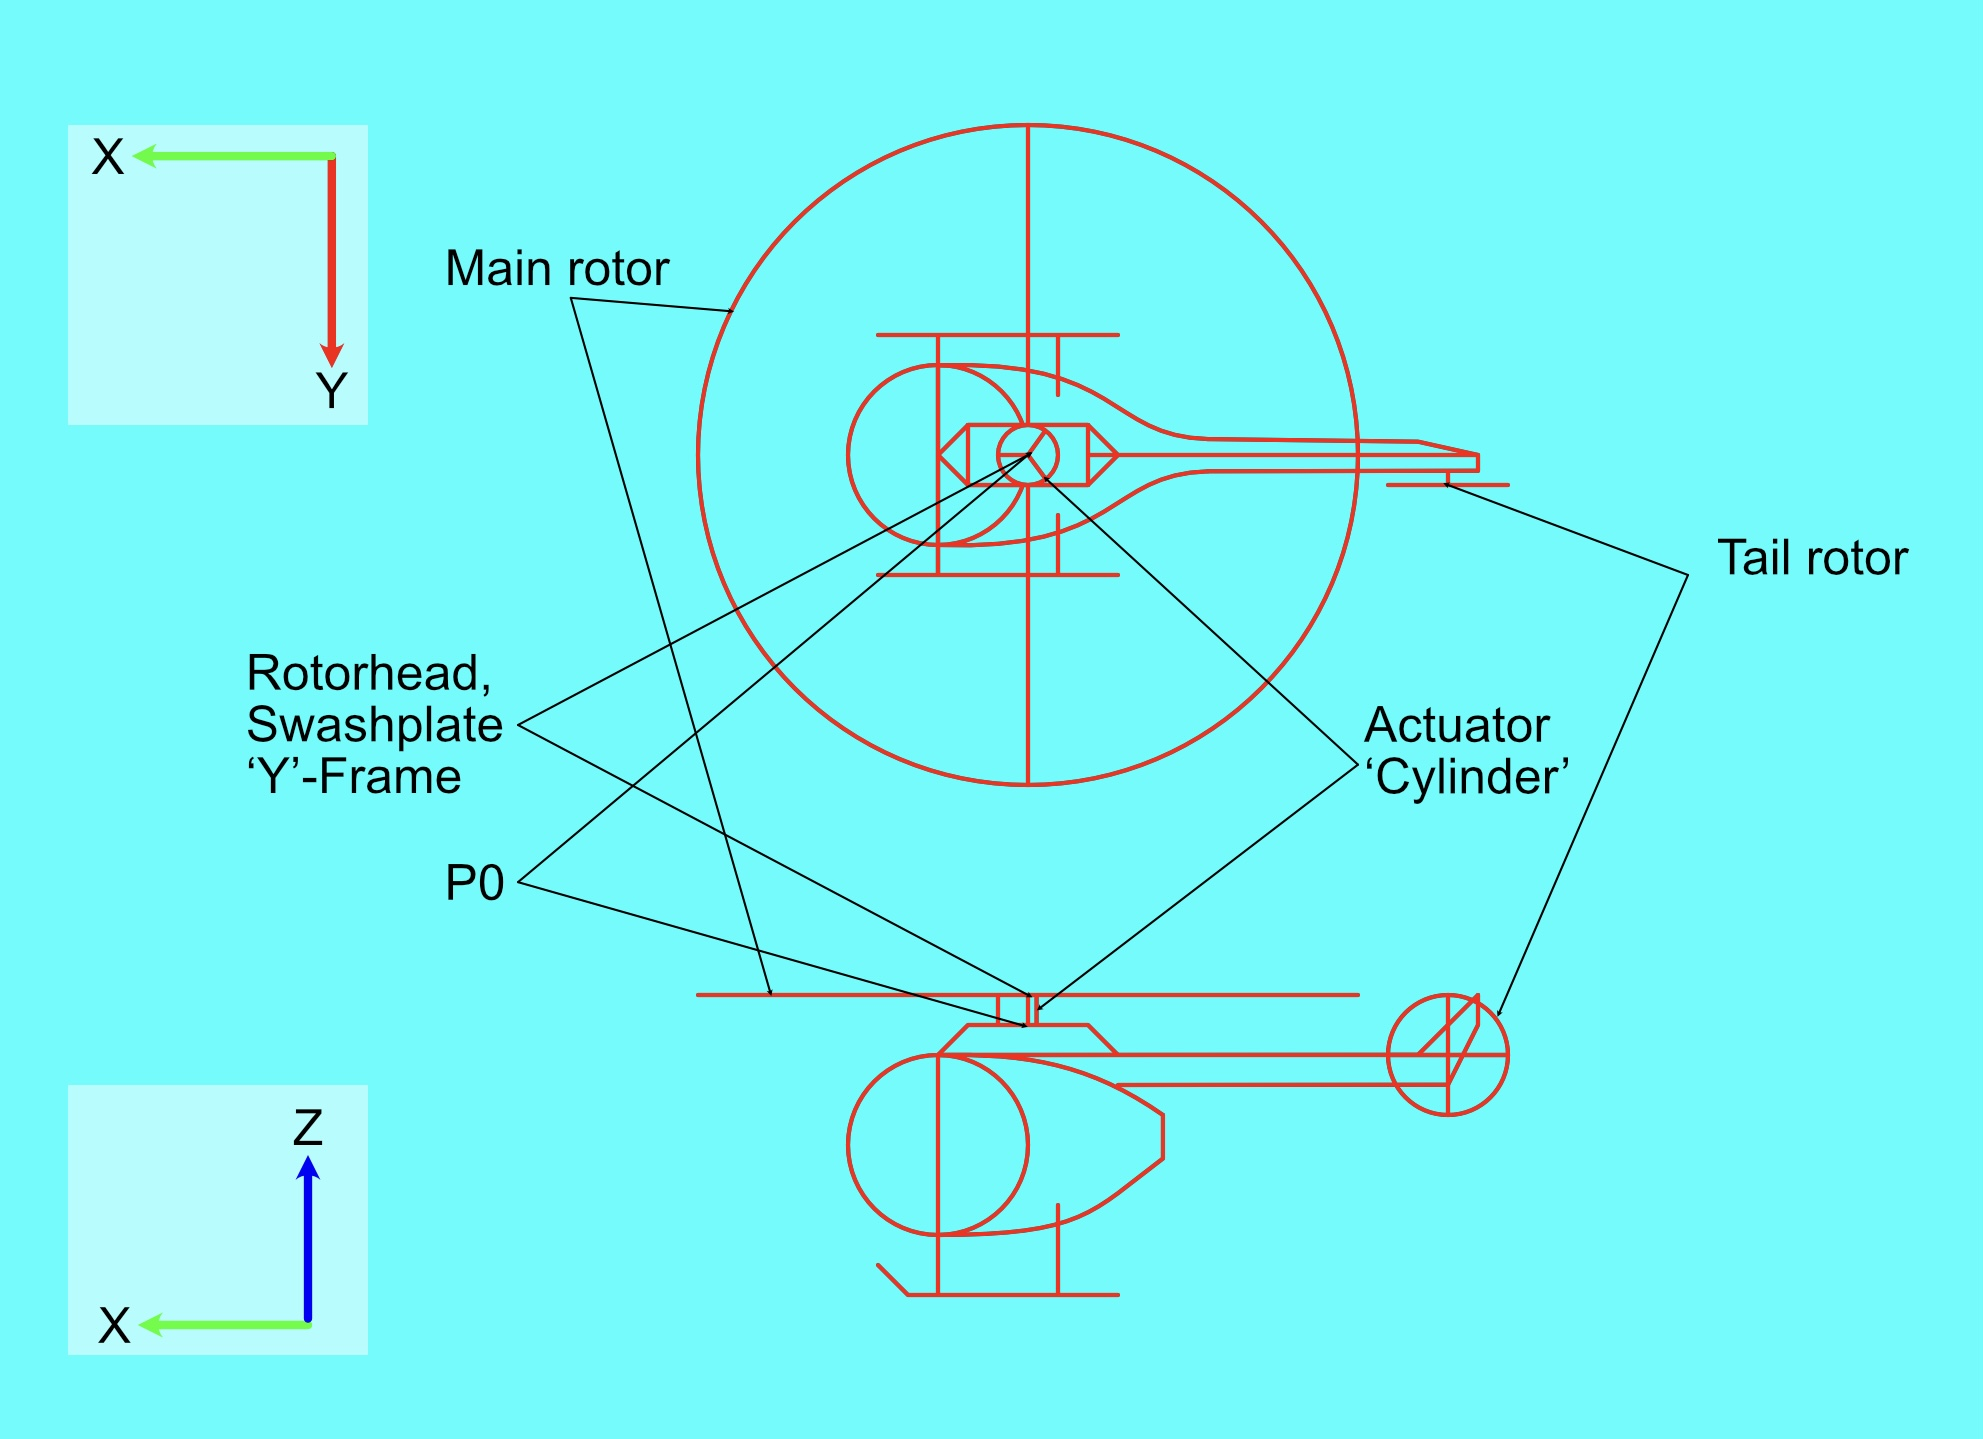

In [10]:
display_image('helidiag.jpg')

In [11]:
from IPython.display import Math

In [12]:
display(Math("{What\ is\ a\ moof?}"+sym.latex(abs(Vr))))




<IPython.core.display.Math object>

In [13]:
from sympy.physics.units import newton, centimeter, kilogram, gram, meter, second, gravitational_constant

In [14]:
1.8*newton*meter

1.8⋅meter⋅newton

In [15]:
15*kilogram*centimeter

15⋅centimeter⋅kilogram

In [16]:
gravitational_constant/newton

gravitational_constant
──────────────────────
        newton        

In [17]:
gac = 9.81*meter/second**2
gac

9.81⋅meter
──────────
       2  
 second   

In [18]:
k = (15*kilogram*gac)
k

147.15⋅kilogram⋅meter
─────────────────────
             2       
       second        

In [19]:
from sympy.physics.units.util import quantity_simplify

In [20]:
quantity_simplify(k)

147.15⋅kilogram⋅meter
─────────────────────
             2       
       second        

### Importing into github
#### I always get this wrong the first eight tries.

https://docs.github.com/en/migrations/importing-source-code/using-the-command-line-to-import-source-code/adding-locally-hosted-code-to-github

if not already setup:

```
123  git config --global --edit
```

```
  126  git init -b main
  127  git add .
  128  git commit -m "First commit"
  129  git remote add origin https://github.com/ivorjawa/Mecanum_lego.git
  130  git remote -v
  131  git push -u origin main
  132  git pull origin main
  # 133  git config pull.rebase false
  # 134  git pull origin main
  135  git config pull.rebase true
  136  git pull origin main
  138  git push -u origin main
```

may need to do a "git checkout -b main" before push to satisfy github.
if origin push fails, "git config http.postBuffer 524288000" may work

In [21]:
import cv2


In [22]:
help(display)

Help on function display in module IPython.core.display_functions:

display(*objs, include=None, exclude=None, metadata=None, transient=None, display_id=None, raw=False, clear=False, **kwargs)
    Display a Python object in all frontends.
    
    By default all representations will be computed and sent to the frontends.
    Frontends can decide which representation is used and how.
    
    In terminal IPython this will be similar to using :func:`print`, for use in richer
    frontends see Jupyter notebook examples with rich display logic.
    
    Parameters
    ----------
    *objs : object
        The Python objects to display.
    raw : bool, optional
        Are the objects to be displayed already mimetype-keyed dicts of raw display data,
        or Python objects that need to be formatted before display? [default: False]
    include : list, tuple or set, optional
        A list of format type strings (MIME types) to include in the
        format data dict. If this is set *only* 

tag: red27 id: 27
tag: blue03 id: 3
tag: green15 id: 15
tag: bubble id: 42


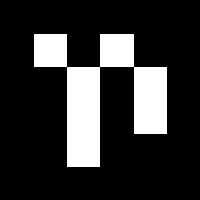

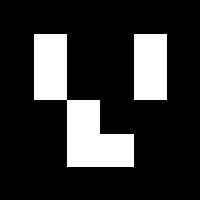

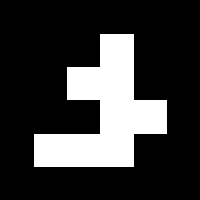

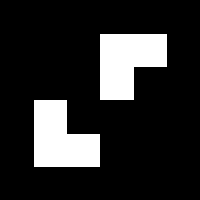

In [23]:
tags = {
    'red27': 27,
    'blue03': 3,
    'green15': 15,
    'bubble': 42,
}

markers = []
for (name, marker_id) in tags.items():
    print(f"tag: {name} id: {marker_id}")
    dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_250)
    #marker_id = 0 # max 249 
    marker_size = 200
    marker_image = cv2.aruco.generateImageMarker(dictionary, marker_id, marker_size)
    #display(plt.imshow(marker_image))
    #markers.append(plt.imshow(marker_image))
    markers.append(marker_image)
    
    tag_name = f"aruco/markers/aruco_{name}_{marker_id}.png"
    cv2.imwrite(tag_name, marker_image)


for ima in markers:
    display_img_array(ima)
    
#

In [24]:
# https://docs.opencv.org/4.x/da/d0d/tutorial_camera_calibration_pattern.html
# https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html

In [25]:
# to remove crlf:
# vim file.txt -c "set ff=unix" -c ":wq"

In [26]:
import svgwrite, base64

''
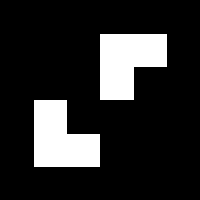

In [27]:
dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_250)
marker_size = 200
marker_image = cv2.aruco.generateImageMarker(dictionary, 42, marker_size)
marker_image.shape
img_encode = cv2.imencode('.png', marker_image)[1]
# Converting the image into numpy array 
#data_encode = np.array(img_encode) 
# Converting the array to bytes. 
#byte_encode = data_encode.tobytes()
byte_encode = img_encode.tobytes()
bbytes = base64.b64encode(byte_encode).decode()
xlink = f"data:image/png;base64,{bbytes}"
xlink

In [28]:
x = [30*(z-12) for z in range(25)]
for ang in x:
    print(f"{ang:5} {(90-(ang%180)):5}")

 -360    90
 -330    60
 -300    30
 -270     0
 -240   -30
 -210   -60
 -180    90
 -150    60
 -120    30
  -90     0
  -60   -30
  -30   -60
    0    90
   30    60
   60    30
   90     0
  120   -30
  150   -60
  180    90
  210    60
  240    30
  270     0
  300   -30
  330   -60
  360    90


In [29]:
steps = np.arange(0, 11, 1)*36
r = 50
x = r*np.cos(np.radians(steps))
y = r*np.sin(np.radians(steps))
z = 0 * steps
np.stack([x, y, z], axis=1)

array([[       50.0000,         0.0000,         0.0000],
       [       40.4508,        29.3893,         0.0000],
       [       15.4508,        47.5528,         0.0000],
       [      -15.4508,        47.5528,         0.0000],
       [      -40.4508,        29.3893,         0.0000],
       [      -50.0000,         0.0000,         0.0000],
       [      -40.4508,       -29.3893,         0.0000],
       [      -15.4508,       -47.5528,         0.0000],
       [       15.4508,       -47.5528,         0.0000],
       [       40.4508,       -29.3893,         0.0000],
       [       50.0000,        -0.0000,         0.0000]])

In [30]:
help(cv2.fillPoly)

Help on built-in function fillPoly:

fillPoly(...)
    fillPoly(img, pts, color[, lineType[, shift[, offset]]]) -> img
    .   @brief Fills the area bounded by one or more polygons.
    .   
    .   The function cv::fillPoly fills an area bounded by several polygonal contours. The function can fill
    .   complex areas, for example, areas with holes, contours with self-intersections (some of their
    .   parts), and so forth.
    .   
    .   @param img Image.
    .   @param pts Array of polygons where each polygon is represented as an array of points.
    .   @param color Polygon color.
    .   @param lineType Type of the polygon boundaries. See #LineTypes
    .   @param shift Number of fractional bits in the vertex coordinates.
    .   @param offset Optional offset of all points of the contours.



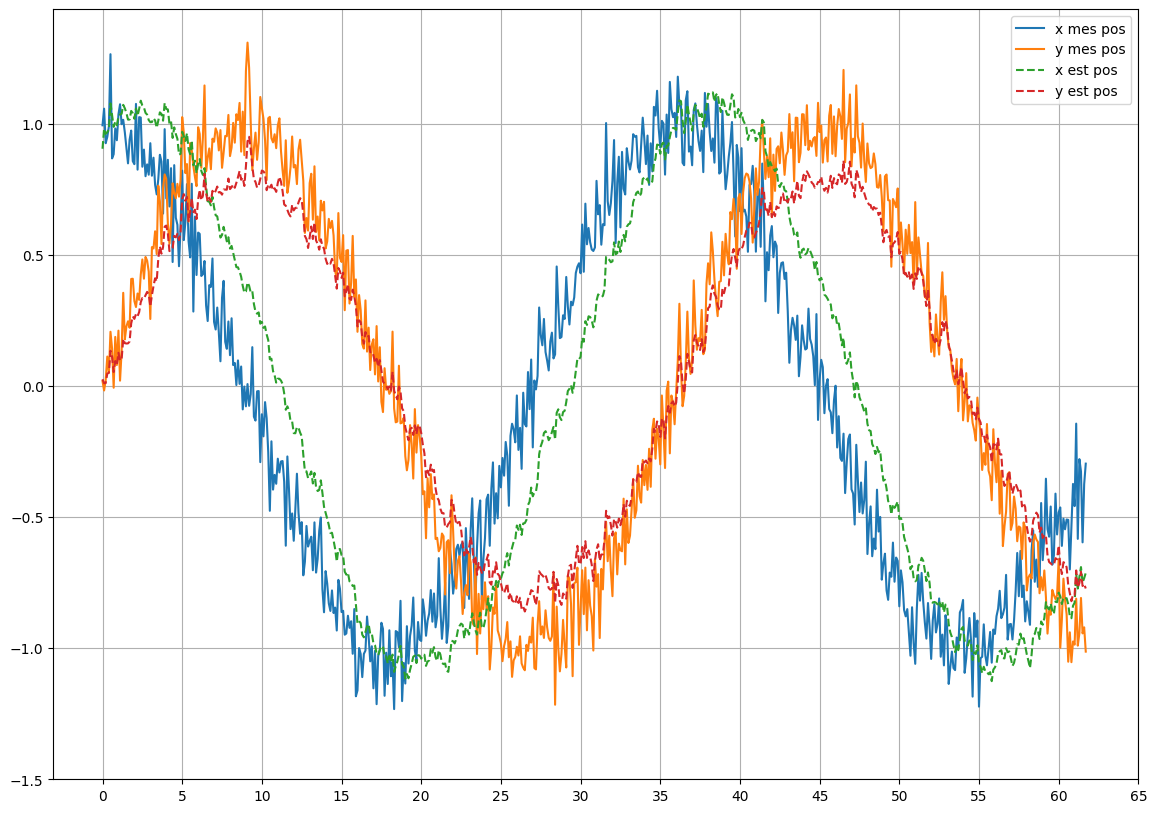

In [31]:
# Define time step
dt = 0.1

# Initialize the filter with an initial estimate of the state matrix and the associated uncertainty (covariance)
x_estimated = np.array([[0], [0], [0], [0]])
P_estimated = np.eye(4)

# Define the state transition matrix
A = np.array([[1, dt, 0, 0], [0, 1, 0, 0], [0, 0, 1, dt], [0, 0, 0, 1]])

# Define the control input matrix as 0
B = np.array([[0], [0], [0], [0]])

# Define the control input as 0
u = np.array([[0], [0], [0], [0]])

# Define the measurement matrix
H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])

# Define the measurement noise
R = np.array([[0.1, 0], [0, 0.1]])

# Define the process noise
Q = np.array([
        [0.01, 0.01, 0.01, 0.01], 
        [0.01, 0.02, 0.01, 0.01], 
        [0.01, 0.01, 0.03, 0.01], 
        [0.01, 0.01, 0.01, 0.04]])

xp = []
xmp = []
yp = []
ymp = []
xv = []
yv = []
for i in range(618):
    # Generate a measurement with some random noise
    #measurement = np.array([[i + np.random.normal(0, 0.1)], [i + np.random.normal(0, 0.1)]])
    measurement = np.array([[np.cos(m.radians(i)) + np.random.normal(0, 0.1)], [np.sin(m.radians(i)) + np.random.normal(0, 0.1)]])



    # Prediction step
    x_predicted = np.dot(A, x_estimated)# + np.dot(B, u)
    P_predicted = np.dot(A, np.dot(P_estimated, A.T)) + Q

    # Correction step
    K = np.dot(P_predicted, np.dot(H.T, np.linalg.inv(np.dot(H, np.dot(P_predicted, H.T)) + R)))
    x_estimated = x_predicted + np.dot(K, (measurement - np.dot(H, x_predicted)))
    P_estimated = np.dot((np.eye(4) - np.dot(K, H)), P_predicted)

    xmp.append(measurement[0])
    ymp.append(measurement[1])

    # Print the estimated position and velocity
    #print("Estimated x_position: ", x_estimated[0][0])
    xp.append(x_estimated[0][0])
    #print("Estimated y_position: ", x_estimated[1][0])
    yp.append(x_estimated[1][0])
    #print("Estimated x_velocity: ", x_estimated[2][0])
    xv.append(x_estimated[2][0])
    #print("Estimated y_velocity: ", x_estimated[3][0])
    yv.append(x_estimated[3][0])
    
    
fig, ax = plt.subplots(figsize=(14, 10))
#ax.set_aspect('equal')

tim = np.array(range(len(xp)))*dt

#ax.plot(xmp, ymp, label = "measured")
#ax.plot(xp, yp, label = "predicted")


ax.plot(tim, xmp, label='x mes pos')
ax.plot(tim, ymp, label='y mes pos')
ax.plot(tim, xp, '--', label='x est pos')
ax.plot(tim, yp, '--',label='y est pos')
ax.set_xticks(np.arange(0, 70, 5))
ax.set_yticks(np.arange(-1.5, 1.5, .5))


ax.grid()
#ax.plot(tim, xv, label='x est vel')
#ax.plot(tim, yv, label='x est vel')



#ax.set_title("Joystick characterization")
#ax.set_xlabel("Time(ms)")

ax.legend()

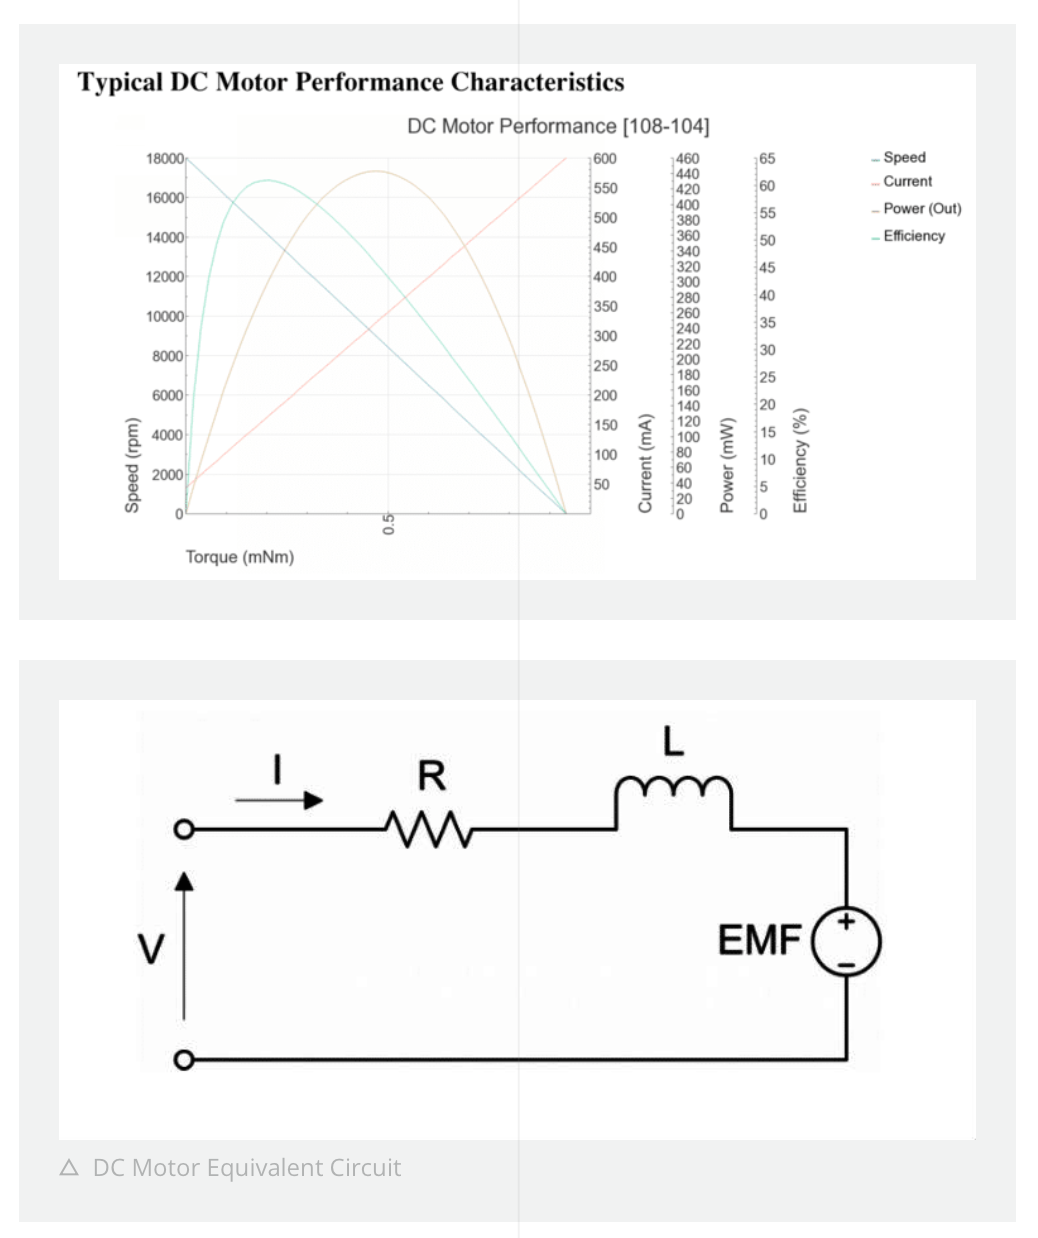

https://www.precisionmicrodrives.com/dc-motor-speed-voltage-and-torque-relationships

DC Motor Speed: Voltage and Torque Relationships
Something we have discussed in the past is how varying the voltage to a vibration motor can change the amplitude, particularly with reference to haptic feedback and playing different effects. However, something we haven’t explicitly shown is why this happens, or discussed it in the context of a normal DC motor. So in this short article, we will demonstrate how an increased voltage will increase the speed and an increased load will decrease the speed of a motor.

It is important to note that this is valid for all of our products that are based on brushed DC motors, so it applies to:

DC motors, directly
DC gearmotors, directly with a simple mechanical speed reduction
Vibration motors, which have a fixed load
We start with the equivalent circuit of a brushed DC motor:

A typical DC motor performance graph using the 108-104
a DC motor equivalent circuit
DC Motor Equivalent Circuit
Using a simple voltage loop we can see that the input voltage (\(V)\) is equal to the voltage drop across the coil resistance (\(R)\) and the inductor (\(L)\), with the back EMF (\(E)\) produced by the motor in motion, i.e.:

$$V = IR + L \frac{dI}{dt} + E$$

However, to demonstrate the effect voltage and torque have on speed, we are only concerned with steady-state behaviour at the moment. In steady-state we benefit from two simplifications:

First, the current is constant which means the inductor \( L\) can be removed
Secondly, as there is no change in speed, the torque produced by the motor and the torque produced by the load must be equal
The second simplification helps as we consider how torque is produced in the motor, given by the following equation:

$$T = K_{T} \phi I$$

Where \(K_{T}\) represents a constant inherited from its internal design, \(\phi\) is the total flux and \(T\) can represent our load torque. We rearrange this for \(I\) and enter it into our original equation:

$$V = \frac{T}{K_{T} \phi} R + E$$

Now we turn our attention to the emf \(E\), which is dependent upon the total flux \(\phi\) motor specific factors (such as its radius and length) that make a second constant \(K_{E}\) and the speed of the motor \(n\):

$$E = K_{E} \phi n$$

Substituting this value of \(E\) into our equation yields the following:

$$V = \frac{T}{K_{T} \phi} R + K_{E} \phi n$$

The equation above actually represents a linear motor, in adapting this to an angular rotating motor we consider the flux to be constant at its full value. In doing so it is combined with each constant to produce the torque constant and electrical constant of the motor, denoted \(k_{t}\) and \(k_{e}\) respectively. As discussed before, these constants actually share the same units, so we can replace both constants in our equation to the value \(k\). Also, we now replace linear speed \(n\) with angular velocity \(\omega\), so our equation becomes:

$$V = \frac{T}{k} R + k \omega$$

Rearranged for angular velocity:

$$\omega = \frac{V}{k} – \frac {T}{k^{2}} R$$

In summary, we can highlight the two main variables which affect the speed of the motor in our final equation:

Input Voltage:  For a fixed load, the speed of the motor is affected by the applied voltage. Increase in voltage = increase in speed
Load Torque: For a fixed voltage, the speed of the motor is inversely affected by the load. Increase in load torque = decrease in speed
If you have any questions about this relationship, or how the theory applies to a ‘real-world’ motor, please contact our sales engineers to help with your application.

In [32]:
# https://docs.sympy.org/latest/guides/solving/find-roots-polynomial.html
# https://stackoverflow.com/questions/22089150/factor-to-complex-roots-using-sympy
s = sym.Symbol('s')
sym.factor(s**2+1, gaussian=True)

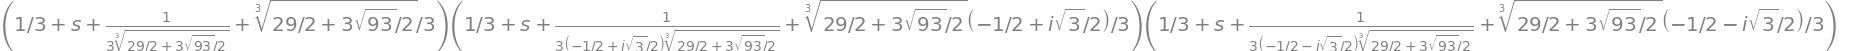

In [33]:
#sym.factor(, gaussian=True)
p = s**3 + s**2 + 1
r = sym.roots(p, s)
sym.LC(p, s)*sym.Mul(*[(s - a)**r[a] for a in r])

In [34]:
sym.roots(s**2+1, s)

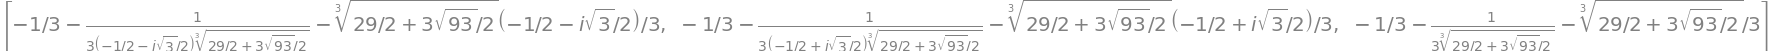

In [35]:
sym.solve(p, s, quartics=False)

In [36]:
# https://stackoverflow.com/questions/69400843/how-to-get-repeating-roots-in-sympy
    
eqn = s**2 - 2*s + 1
#sym.solveset(eqn, s)
eqn.as_poly()
r = sym.roots(eqn.as_poly())
r

In [37]:
sym.LC(eqn, s)*sym.Mul(*[(s - a)**r[a] for a in r])

In [38]:
(-1 + s) * (-1 + s)

In [39]:
eqn

In [40]:
eqn = s**2 - 8*s + 16
eqn

In [41]:
sym.roots(eqn)

In [42]:
# https://en.wikipedia.org/wiki/Damping

In [43]:
num = 10**4*(s+6000)
den = s**2 +875*s +88*10e6
num/den

In [44]:
sym.roots(den, s)

In [45]:
r = sym.roots(den, s)
sym.LC(den, s)*sym.Mul(*[(s - a)**r[a] for a in r])

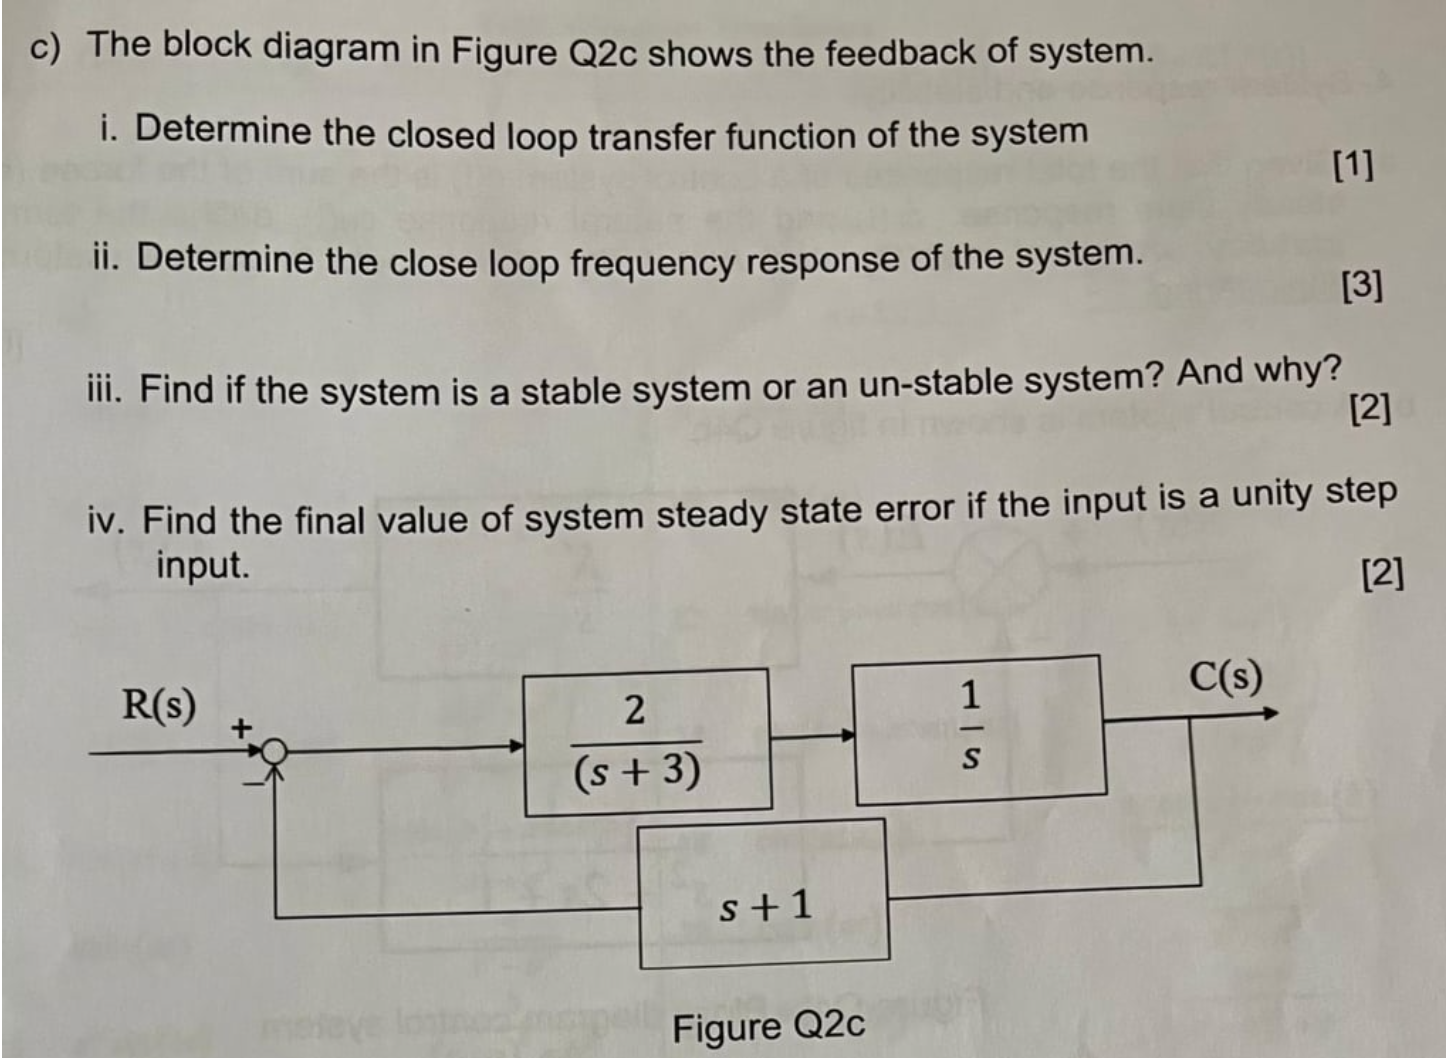

The first question is pretty easy. You just set up a set of 2 equations: R(s) = input signal, r stands for reference, and it's value indicstes the desired output signal. C(s) = The actual output signal E(s) =R(s)-(s+1)×C(s) This equation comes from the summing point. You're feeding back the output through a (s+1) block. C(s)=2/(s(s+3))×E(s) (block simplification) The closed loop transfer function is the ratio C(s) / R(s), which you can derive after substituting E(s) into the first equation and doing some algebra. For the next questions, you need to learn to draw two diagrams : a bode plot (tells you the frequency response) and a root locus diagram (indicates stability as a function of the gain of the system). For the steady state response, you must take a limit as s-> 0 of the output times s. Look up final value theorem in the s domain.

In [46]:
# https://www.reddit.com/r/ControlTheory/comments/1dh641c/exam_question_help/

In [47]:
num = 2
den = s**2 + 4*s + 1
sym.roots(den, s)

In [48]:
r = sym.roots(den, s)
sym.LC(den, s)*sym.Mul(*[(s - a)**r[a] for a in r])

In [49]:
import scipy.signal as signal
import control


In [50]:
#den2 = [(-a)**r[a] for a in r]
#[num], den2
tf = signal.TransferFunction([2], [1, 4, 1])
tf, tf.poles, tf.zeros

(TransferFunctionContinuous(
 array([        2.0000]),
 array([        1.0000,         4.0000,         1.0000]),
 dt: None
 ),
 array([       -3.7321,        -0.2679]),
 array([], dtype=float64))

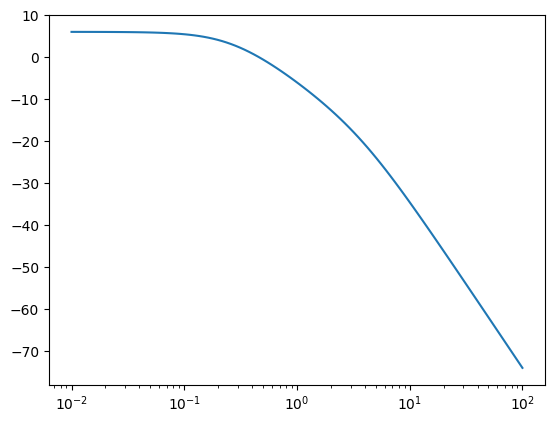

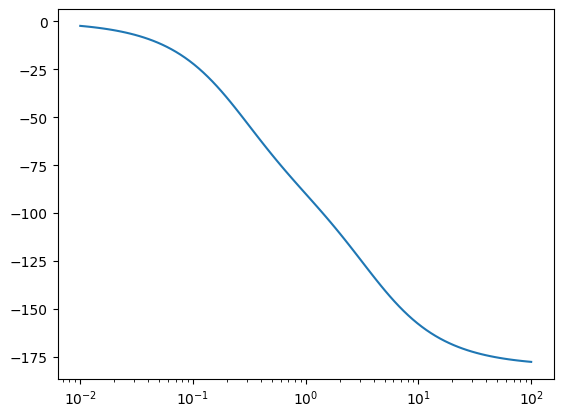

In [51]:
w, mag, phase = signal.bode(tf)
#w, mag, phase
plt.figure()
plt.semilogx(w, mag)    # Bode magnitude plot
plt.figure()
plt.semilogx(w, phase)  # Bode phase plot
plt.show()

In [52]:
z, p, k = signal.tf2zpk(tf.num, tf.den)
z, p, k

(array([], dtype=float64), array([       -3.7321,        -0.2679]), 2.0)

In [53]:
from sympy.physics.control.lti import TransferFunction as symtf
from sympy.physics.control.control_plots import pole_zero_plot

In [54]:
num = 2
den = s**2 + 4*s + 1
tf2 = symtf(num, den, s)
tf2

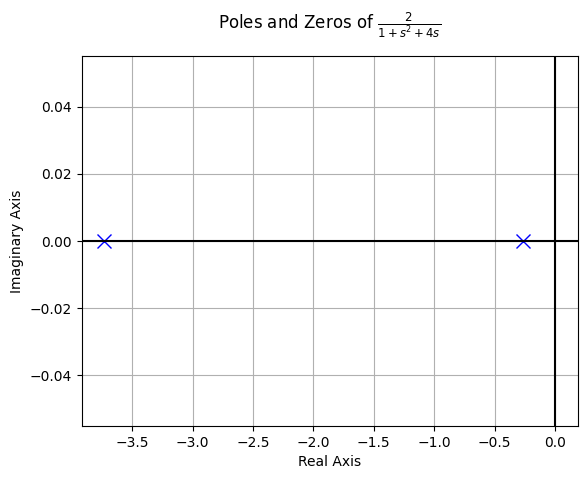

In [55]:
pole_zero_plot(tf2) 

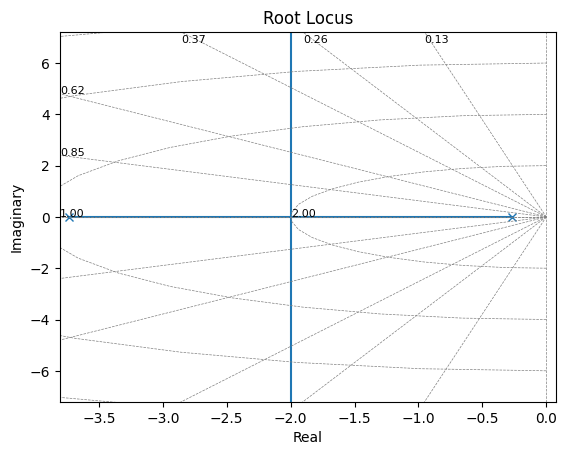

In [56]:
G = control.TransferFunction([2], [1, 4, 1])
rlist, klist = control.rlocus(G)#, kvect=np.linspace(100.0, -100.0, num=1000))
plt.show()

QgridWidget(grid_options={'fullWidthRows': True, 'syncColumnCellResize': True, 'forceFitColumns': False, 'defa…

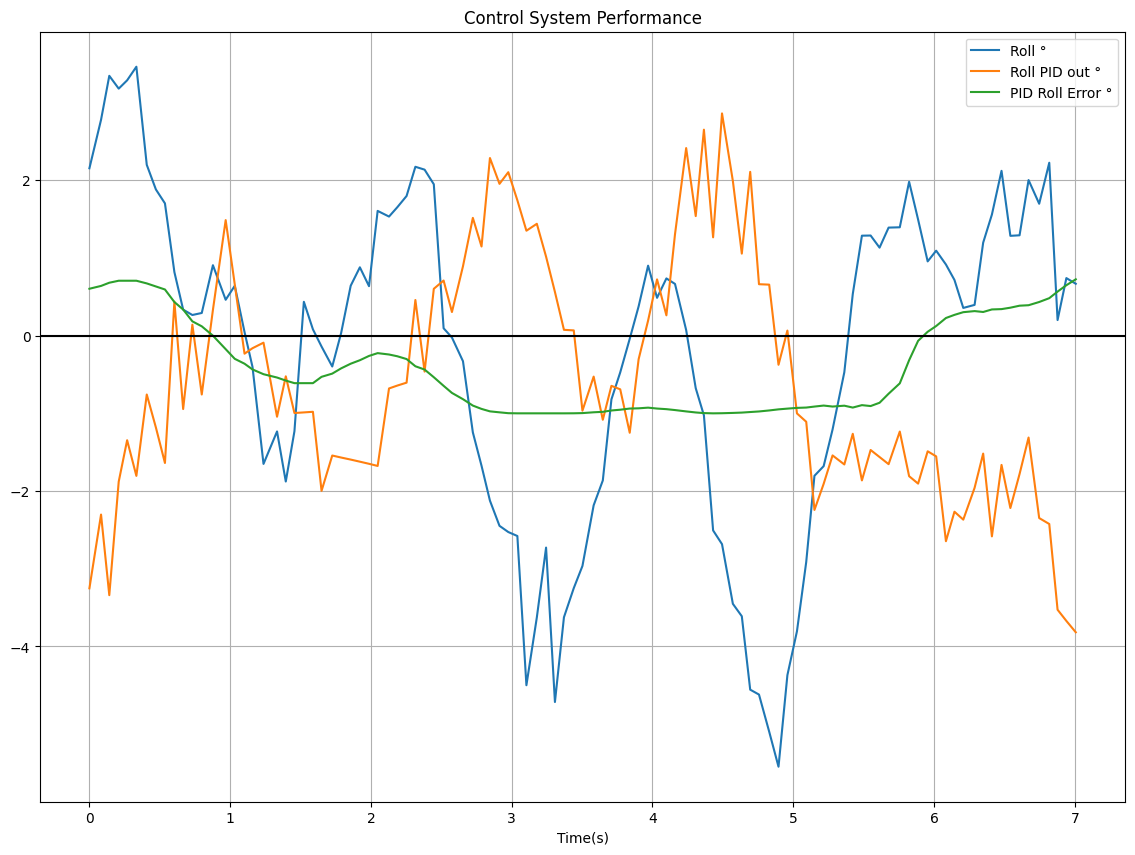

In [57]:
class TableGrapher(object):
    ds = u'\N{DEGREE SIGN}'
    ptoo = u'\N{PROPORTIONAL TO}'
    def __init__(self, 
                 filename=None, 
                 dataframe=None, 
                 figsize=(14,10), 
                 title="Table Graph",
                 grid=True,
                 axhline=True,
                 xalabel="Time(s)"
                ):
        if not (dataframe is None):
            self.df = dataframe
        elif not (filename is None):
            self.df = pd.read_csv(filename)
        else:
            self.df = None
        
        self.asnum = lambda k: self.df[k].to_numpy()
        
        dftime = self.asnum('time')
        dftime = dftime - dftime[0]
        self.df['time'] = dftime
        self.time = dftime
        
        self.figsize = figsize
        self.fig, self.axis = plt.subplots(figsize=figsize)
        
        self.title = title
        self.grid = grid
        self.axhline = axhline
        self.xalabel = xalabel
    def draw(self):
        pass
    def plot(self):
        display(qgrid.show_grid(self.df, 
                grid_options={'forceFitColumns': False, 'defaultColumnWidth': 100},
                show_toolbar=True)) # display database as spreadsheet
        self.draw()
        self.axis.set_title(self.title)
        self.axis.set_xlabel(self.xalabel)
        if self.axhline:
            self.axis.axhline(0,color='black')
        if self.grid:
            self.axis.grid()
        self.axis.legend()
        #display(self.axis)
        return None
        

class MPCTG(TableGrapher):
    def draw(self):
        self.title = "Control System Performance"
        roll = self.asnum('roll') 
        rpe = self.asnum('roll_pid_out')*5 # pid output -1..1, but represents +- 5 degrees
        rollerr = self.asnum('rollerr')/self.asnum('ballradscale')
        #cx = self.asnum('c3x')/pscale # higher numbers, like c3x have newer data than c2x, etc
        #cy = self.asnum('c3y')/pscale # center of ball as detected
        self.axis.plot(self.time, roll, label=f"Roll {self.ds}")
        self.axis.plot(self.time, rpe, label=f"Roll PID out {self.ds}")
        self.axis.plot(self.time, rollerr, label=f"PID Roll Error {self.ds}")
        
mpctg = MPCTG("Pose_est-2024-07-10T16:29:02.535556.csv")
mpctg.plot()



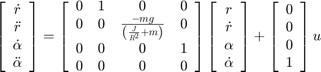

In [58]:
# https://www.bricklink.com/v2/catalog/catalogitem.page?P=41250#T=C
# Ball, Hard Plastic 52mm D, page has mass
ms = 13.9/1000 # ball mass: g->kg 
R = 26/1000 # ball radius: mm->m
# https://www.quora.com/What-is-the-volume-of-plastic-in-a-4x2-Lego-brick
ρ_ABS = 1070 # density of ABS plastic: 1070 kg/m^3
v_ABS = ms/ρ_ABS # volume of ABS in m^3
vsph = lambda r: (4/3)*m.pi*r**3
osm = vsph(R)*ρ_ABS
rvol = lambda M, ρ: ((3*M)/(4*m.pi*ρ))**(1/3)
Ris = rvol(osm-ms, ρ_ABS) # inner shell to subtracted
jsphsh = lambda r1, r2, m: (2/5)*m*( (r2**5 - r1**5) / (r2**3 - r1**3) )
J = jsphsh(Ris, R, ms)
g = -9.807 #m/s^2
H = -ms*g/(J/(R**2)+ms)

A = np.array([ 
    [0, 1, 0, 0],
    [0, 0, H, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 0]
] )
B = np.array([[0], [0], [0], [1]])
C = np.array([1,  1,  1, 0])
D = np.array([0])
#ball_ss = signal.StateSpace(A, B, C, D, dt=50/1000)
ball_ss = signal.StateSpace(A, B, C, D)
#A, B, C, D, ball_ss
ball_ss

StateSpaceContinuous(
array([[        0.0000,         1.0000,         0.0000,         0.0000],
       [        0.0000,         0.0000,         6.0290,         0.0000],
       [        0.0000,         0.0000,         0.0000,         1.0000],
       [        0.0000,         0.0000,         0.0000,         0.0000]]),
array([[0],
       [0],
       [0],
       [1]]),
array([[1, 1, 1, 0]]),
array([[0]]),
dt: None
)

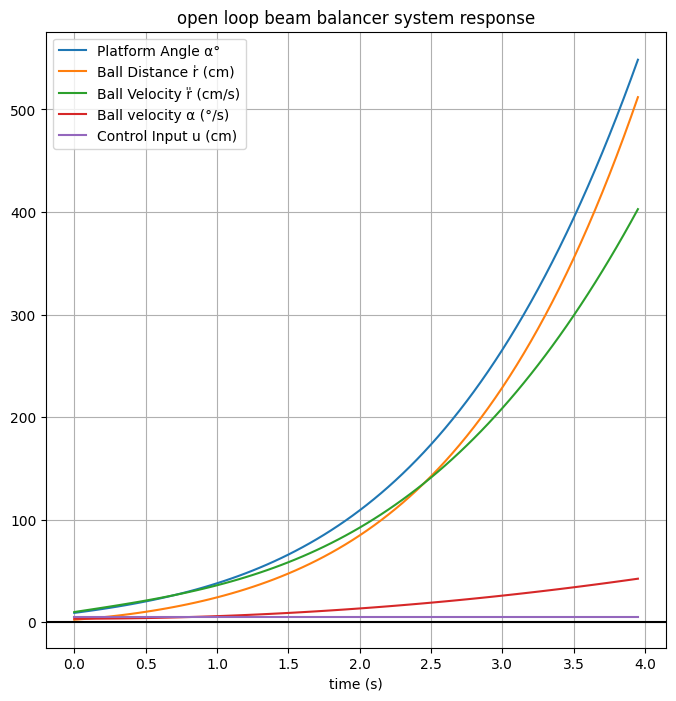

In [59]:
ds = u'\N{DEGREE SIGN}'
t = np.arange(0, 4, 50/1000) # 4 seconds, 50ms interval
#u = 0 * t
u = np.ones(len(t)) * (50/1000) 
x0 = np.array([25/1000, 100/1000, np.radians(2), 0]) # 25 mm, 100 mm/s, 2 degrees

dot = '\u030d'
dot2 = '\u030e'
rdot = 'r' + dot
rdot2 = 'r' + dot2


T, yout, xout =  signal.lsim(ball_ss, u, t, x0)
fig, axes = plt.subplots(figsize=(8,8), dpi=100)
#axes.plot(T, xout.transpose()[2], label = "xout")
axes.plot(T, np.degrees(yout), label = f"Platform Angle α{ds}")
axes.plot(T, xout.T[0]*100, label = f"Ball Distance {rdot} (cm)")
axes.plot(T, xout.T[1]*100, label = f"Ball Velocity {rdot2} (cm/s)")
axes.plot(T, xout.T[2]*100, label = f"Ball velocity α ({ds}/s)")

axes.plot(T, u*100, label = f"Control Input u (cm)")
axes.set_xlabel("time (s)")
axes.set_title("open loop beam balancer system response")
axes.axhline(0,color='black')
axes.grid()
axes.legend()
None

In [60]:
wD_eigvals_poles, vT_eigvecs = np.linalg.eig(A) # parames reversed from matlab
wD_eigvals_poles, vT_eigvecs

(array([        0.0000,         0.0000,         0.0000,         0.0000]),
 array([[        1.0000,        -1.0000,         1.0000,        -1.0000],
        [        0.0000,         0.0000,        -0.0000,         0.0000],
        [        0.0000,         0.0000,         0.0000,        -0.0000],
        [        0.0000,         0.0000,         0.0000,         0.0000]]))

In [61]:
cbss = control.StateSpace(A, B, C, D)


In [62]:
cbtf = control.ss2tf(cbss)
cbtf

TransferFunction(array([       -0.0000,         1.0000,         6.0290,         6.0290]), array([        1.0000,         0.0000,         0.0000,         0.0000,
               0.0000]))

In [63]:
cbss.zeros(), cbss.poles()

(array([-4.76327605+0.j, -1.26572592+0.j]),
 array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]))

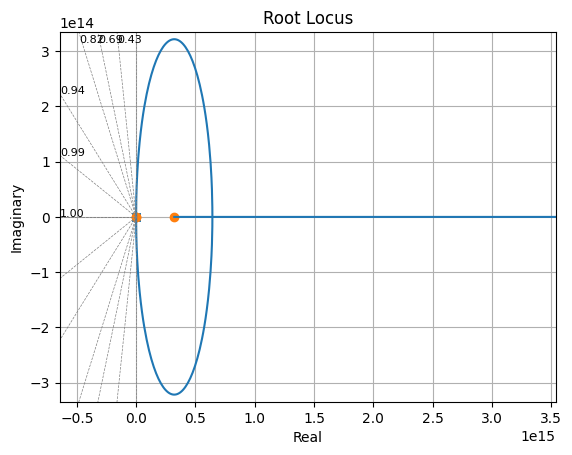

In [64]:
rlist, klist = control.rlocus(cbtf)#, kvect=np.linspace(100.0, -100.0, num=1000))
plt.grid()
#plt.legend()
plt.show()

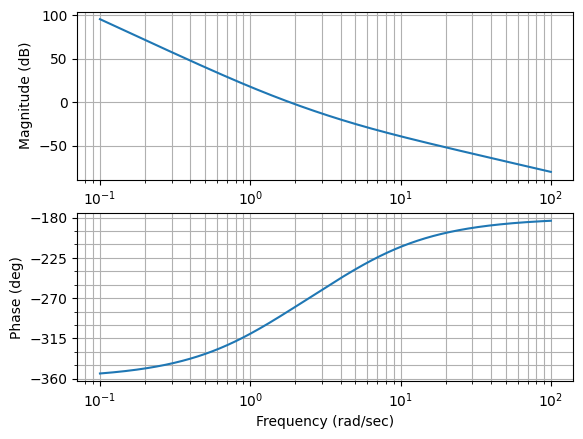

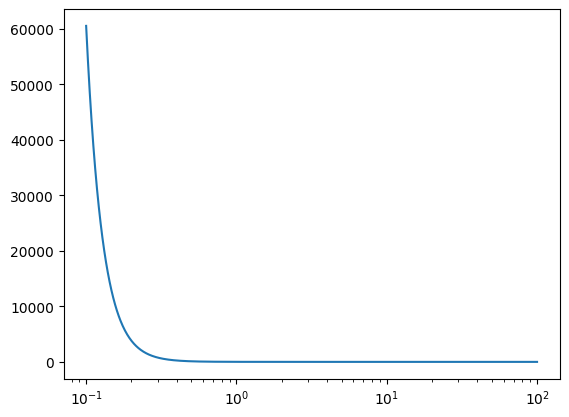

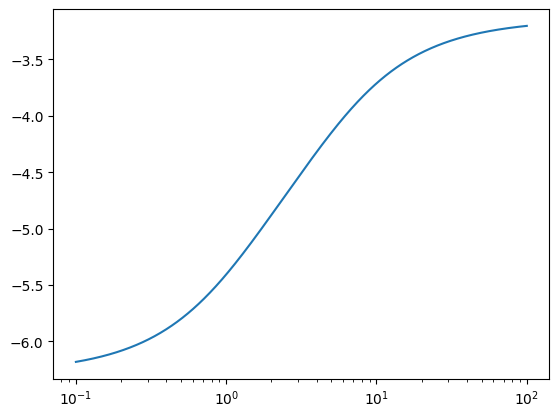

In [65]:
import control.matlab
mag, phase, omega = control.matlab.bode(cbss)
#w, mag, phase
plt.figure()
plt.semilogx(omega, mag)    # Bode magnitude plot
plt.figure()
plt.semilogx(omega, phase)  # Bode phase plot
plt.show()

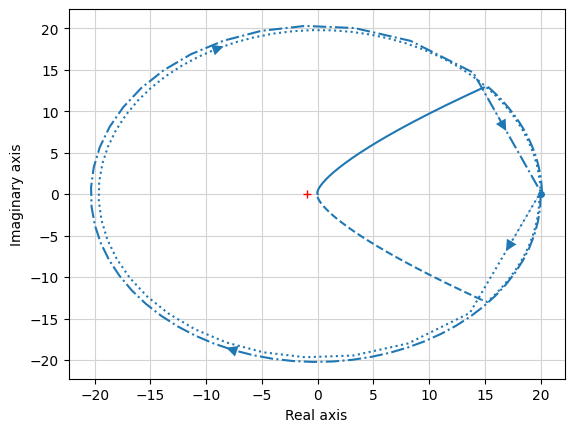

In [66]:
control.nyquist(cbss)

(array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]),
 array([-4.76327605+0.j, -1.26572592+0.j]))

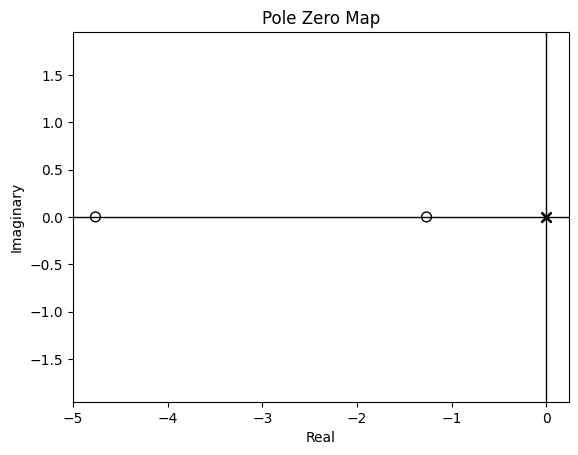

In [67]:
control.matlab.pzmap(cbss)

In [68]:
p1 = -2+2j
p2 = -2-2j
p3 = -20;
p4 = -80;

K = control.place(A, B, [p1, p2, p3, p4])
K

matrix([[     2123.0711,      1194.2275,      2008.0000,       104.0000]])

In [69]:
sys_cl = signal.StateSpace(A-B*K, B, C, D)
sys_cl

StateSpaceContinuous(
matrix([[        0.0000,         1.0000,         0.0000,         0.0000],
        [        0.0000,         0.0000,         6.0290,         0.0000],
        [        0.0000,         0.0000,         0.0000,         1.0000],
        [    -2123.0711,     -1194.2275,     -2008.0000,      -104.0000]]),
array([[0],
       [0],
       [0],
       [1]]),
array([[1, 1, 1, 0]]),
array([[0]]),
dt: None
)

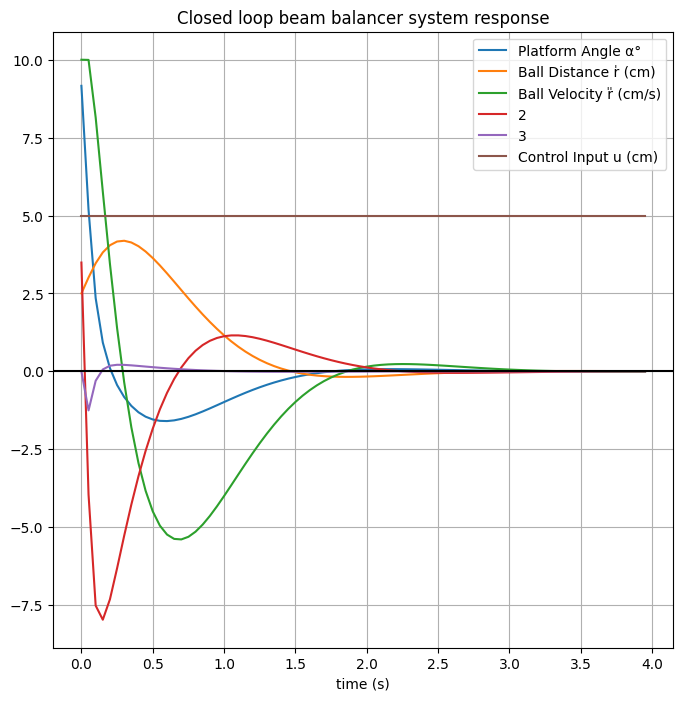

In [70]:
T, yout, xout =  signal.lsim(sys_cl, u, t, x0)
fig, axes = plt.subplots(figsize=(8,8), dpi=100)
#axes.plot(T, xout.transpose()[2], label = "xout")
axes.plot(T, np.degrees(yout), label = f"Platform Angle α{ds}")
axes.plot(T, xout.T[0]*100, label = f"Ball Distance {rdot} (cm)")
axes.plot(T, xout.T[1]*100, label = f"Ball Velocity {rdot2} (cm/s)")
axes.plot(T, xout.T[2]*100, label = f"2")
axes.plot(T, xout.T[3], label = f"3")


axes.plot(T, u*100, label = f"Control Input u (cm)")
axes.set_xlabel("time (s)")
axes.set_title("Closed loop beam balancer system response")
axes.axhline(0,color='black')
axes.grid()
axes.legend()
None

In [71]:
def rscale(a_, b_, c_, d_, k_):
    "This function will find the scale factor for a full-state feedback system to eliminate the steady-state error."
    # https://www.ee.usyd.edu.au/tutorials_online/matlab/extras/rscale.html
    # http://octave-online.net
    # https://docs.scipy.org/doc/numpy-dev/user/numpy-for-matlab-users.html
    s = a_.shape[0]
    print("s:", s)
    z = np.concatenate((np.zeros((1, s))[0], [1]), axis=0)
    print("z:", z)
    top = np.concatenate((a_, b_), axis=1)
    bot = np.concatenate((c_, d_), axis=0)
    tot = np.vstack((top, bot))
    print("tot:", tot)
    N = np.linalg.inv(tot).dot(z)
    print("N: ", N)
    Nx = N[0:s]
    print("Nx", Nx)
    Nu = N[s]
    print("Nu:", Nu)
    Nbar = Nu + k_.dot(Nx)
    print("Nbar", Nbar)
    return Nbar[0]

Nbar = rscale(A, B, C, D, K)
Nbar

s: 4
z: [        0.0000         0.0000         0.0000         0.0000
         1.0000]
tot: [[        0.0000         1.0000         0.0000         0.0000
          0.0000]
 [        0.0000         0.0000         6.0290         0.0000
          0.0000]
 [        0.0000         0.0000         0.0000         1.0000
          0.0000]
 [        0.0000         0.0000         0.0000         0.0000
          1.0000]
 [        1.0000         1.0000         1.0000         0.0000
          0.0000]]
N:  [        1.0000         0.0000         0.0000         0.0000
         0.0000]
Nx [        1.0000         0.0000         0.0000         0.0000]
Nu: 0.0
Nbar [[     2123.0711]]


matrix([[     2123.0711]])

In [72]:
nsys_cl = signal.StateSpace(A-B*K, B*Nbar, C, D)
nsys_cl



StateSpaceContinuous(
matrix([[        0.0000,         1.0000,         0.0000,         0.0000],
        [        0.0000,         0.0000,         6.0290,         0.0000],
        [        0.0000,         0.0000,         0.0000,         1.0000],
        [    -2123.0711,     -1194.2275,     -2008.0000,      -104.0000]]),
matrix([[        0.0000],
        [        0.0000],
        [        0.0000],
        [     2123.0711]]),
array([[1, 1, 1, 0]]),
array([[0]]),
dt: None
)

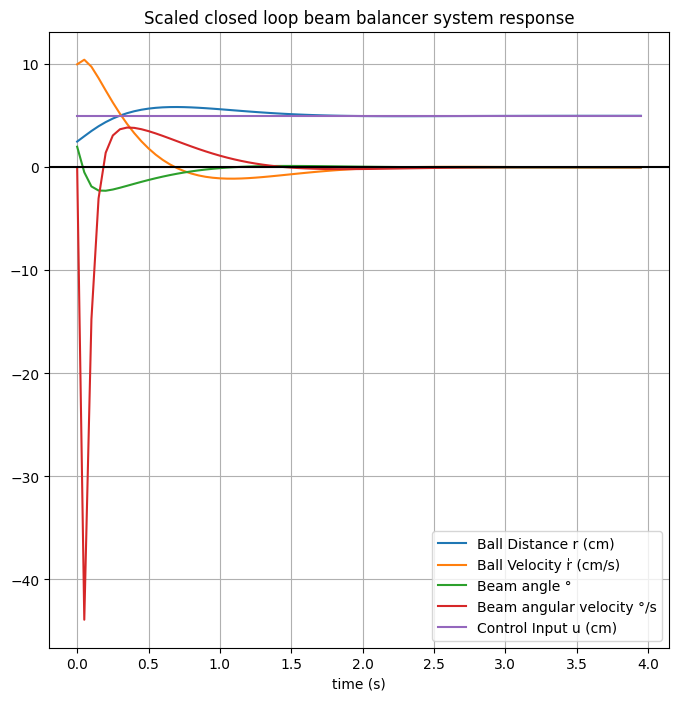

In [73]:
T, yout, xout =  signal.lsim(nsys_cl, u, t, x0)
fig, axes = plt.subplots(figsize=(8,8), dpi=100)
#axes.plot(T, np.degrees(yout), label = f"Platform Angle α{ds}")
axes.plot(T, xout.T[0]*100, label = f"Ball Distance r (cm)")
axes.plot(T, xout.T[1]*100, label = f"Ball Velocity {rdot} (cm/s)")
axes.plot(T, np.degrees(xout.T[2]), label = f"Beam angle {ds}")
axes.plot(T, np.degrees(xout.T[3]), label = f"Beam angular velocity {ds}/s")
axes.plot(T, u*100, label = f"Control Input u (cm)")
axes.set_xlabel("time (s)")
axes.set_title("Scaled closed loop beam balancer system response")
axes.axhline(0,color='black')
axes.grid()
axes.legend()
None

In [74]:

class SSTG(TableGrapher):
    def draw(self):
        pass
        
#sstg = SSTG(dataframe=pd.DataFrame(xout))
#sstg.plot()
dxo = {"t": T, 
       "dist": xout.T[0]*1000, 
       "vel": xout.T[1]*1000, 
       "beam angle": np.degrees(xout.T[2]), 
       "beam α": np.degrees(xout.T[3])}
display(qgrid.show_grid(pd.DataFrame(dxo), 
                grid_options={'forceFitColumns': False, 'defaultColumnWidth': 100},
                show_toolbar=True)) # display database as spreadsheet

QgridWidget(grid_options={'fullWidthRows': True, 'syncColumnCellResize': True, 'forceFitColumns': False, 'defa…

In [75]:
def cbneighbors(x,y,xsize=8,ysize=6):
    even = lambda n: n % 2 == 0
    
    maxx = xsize-1
    maxy = ysize-1
    
    if sum([(x > maxx), (x < 0), (y > maxy), (y < 0)]) > 0:
        raise IndexError(f"x: {x} maxx: {maxx} y: {y} maxy: {maxy}")
        
    up = (x, y + 1)
    down = (x, y - 1)
    left = (x - 1, y)
    right = (x + 1, y)
    
    #print(f"x: {x} y: {y} up: {up} down: {down} left: {left} right: {right}")
    xparts = []
    yparts = []
    
    if sum([(x < maxx), (x > 0), (y < maxy), (y > 0)]) == 4:
        return [up, down, left, right]
    
    if x == 0:
        xparts = [right]
        if even(y):
            yparts = [up]
        else:
            yparts = [down]
    else: # x == maxx:
        xparts = [left]
        if even(y):
            yparts = [up]
        else:
            yparts = [down]
    
    if y == 0:
        yparts = [up]
        if even(x):
            xparts = [right]
        else:
            xparts = [left]
    else: # y == maxy: 
        yparts = [down]
        if even(x):
            xparts = [right]
        else:
            xparts = [left]
        
    return xparts+yparts

cbneighbors(0, 0)
cbneighbors(1, 0)
cbneighbors(1, 1)

In [76]:
cbneighbors(2,4)

In [77]:
import collections

class Queue:
    def __init__(self):
        self.elements = collections.deque()
    def empty(self) -> bool:
        return not self.elements
    def put(self, x: T):
        self.elements.append(x)
    def get(self) -> T:
        return self.elements.popleft()
    

def bfs(start = (0, 0), goal = (4, 4)): # cbneighbors, cost define the system
    # print out what we find
    frontier = Queue()
    frontier.put(start)
    reached = set()
    reached.add(start)
    came_from = {}
    came_from[start] = None
    
    while not frontier.empty():
        current = frontier.get()
        
        if current == goal: 
            print(f"found goal! {goal}")
            break
            
        print(f"  Visiting {current}")
        for next in cbneighbors(*current):
            if next not in reached:
                frontier.put(next)
                reached.add(next)
                came_from[next] = current
    print(f"found {len(reached)} points")
    return came_from
                
#bfs( (4,4),  (0, 0))
bfs()

  Visiting (0, 0)
  Visiting (1, 0)
  Visiting (0, 1)
  Visiting (1, 1)
  Visiting (1, 2)
  Visiting (2, 1)
  Visiting (1, 3)
  Visiting (0, 2)
  Visiting (2, 2)
  Visiting (2, 0)
  Visiting (3, 1)
  Visiting (1, 4)
  Visiting (0, 3)
  Visiting (2, 3)
  Visiting (3, 2)
  Visiting (3, 0)
  Visiting (4, 1)
  Visiting (1, 5)
  Visiting (0, 4)
  Visiting (2, 4)
  Visiting (3, 3)
  Visiting (4, 2)
  Visiting (4, 0)
  Visiting (5, 1)
  Visiting (0, 5)
  Visiting (2, 5)
  Visiting (3, 4)
  Visiting (4, 3)
  Visiting (5, 2)
  Visiting (5, 0)
  Visiting (6, 1)
  Visiting (3, 5)
found goal! (4, 4)
found 37 points


{(0, 0): None,
 (1, 0): (0, 0),
 (0, 1): (0, 0),
 (1, 1): (1, 0),
 (1, 2): (1, 1),
 (2, 1): (1, 1),
 (1, 3): (1, 2),
 (0, 2): (1, 2),
 (2, 2): (1, 2),
 (2, 0): (2, 1),
 (3, 1): (2, 1),
 (1, 4): (1, 3),
 (0, 3): (1, 3),
 (2, 3): (1, 3),
 (3, 2): (2, 2),
 (3, 0): (2, 0),
 (4, 1): (3, 1),
 (1, 5): (1, 4),
 (0, 4): (1, 4),
 (2, 4): (1, 4),
 (3, 3): (2, 3),
 (4, 2): (3, 2),
 (4, 0): (4, 1),
 (5, 1): (4, 1),
 (0, 5): (1, 5),
 (2, 5): (2, 4),
 (3, 4): (2, 4),
 (4, 3): (3, 3),
 (5, 2): (4, 2),
 (5, 0): (4, 0),
 (6, 1): (5, 1),
 (3, 5): (2, 5),
 (4, 4): (3, 4),
 (5, 3): (4, 3),
 (6, 2): (5, 2),
 (6, 0): (6, 1),
 (7, 1): (6, 1)}

In [78]:
import heapq

class PriorityQueue:
    def __init__(self):
        self.elements: list[tuple[float, T]] = []
    def empty(self) -> bool:
        return not self.elements
    def put(self, item: T, priority: float):
        heapq.heappush(self.elements, (priority, item))
    def get(self) -> T:
        return heapq.heappop(self.elements)[1]

def cost(p1, p2):
    return m.sqrt((p2[0]-p1[0])**2 + (p2[1]-p1[1])**2)

def astar_search(start = (0, 0), goal = (4, 4)):
    frontier = PriorityQueue()
    frontier.put(start, 0)
    came_from = {} # : dict[Location, Optional[Location]] 
    cost_so_far = {} # : dict[Location, float]
    came_from[start] = None
    cost_so_far[start] = 0
    
    while not frontier.empty():
        current = frontier.get() # : Location
        
        if current == goal:
            print(f"found goal {goal} after {len(came_from.keys())} steps")
            break
        
        for next in cbneighbors(*current):
            new_cost = cost_so_far[current] + cost(current, next)
            if next not in cost_so_far or new_cost < cost_so_far[next]:
                cost_so_far[next] = new_cost
                priority = new_cost + cost(next, goal)
                frontier.put(next, priority)
                came_from[next] = current
    
    return came_from, cost_so_far

start = (0, 0)
goal = (4, 4)
came_from, costsofar = astar_search(start, goal)

found goal (4, 4) after 31 steps


In [79]:
#def reconstruct_path(came_from: dict[Location, Location],
#                     start: Location, goal: Location) -> list[Location]:

def reconstruct_path(came_from, start, goal):
    current = goal # : Location 
    path = [] # : list[Location]
    if goal not in came_from: # no path was found
        print(f"goal {goal} not in came_from")
        return []
    while current != start:
        path.append(current)
        current = came_from[current]
    path.append(start) # optional
    path.reverse() # optional
    return path

reconstruct_path(came_from, start, goal)

In [80]:
costsofar

In [81]:
def astar_gen(start = (0, 0), goal = (4, 4)):
    frontier = PriorityQueue()
    frontier.put(start, 0)
    came_from = {} # : dict[Location, Optional[Location]] 
    cost_so_far = {} # : dict[Location, float]
    came_from[start] = None
    cost_so_far[start] = 0
    
    while not frontier.empty():
        current = frontier.get() # : Location
        
        yield reconstruct_path(came_from, start, goal)
        if current == goal:
            print(f"found goal {goal} after {len(came_from.keys())} steps")
            return
            #break
        
        for next in cbneighbors(*current):
            new_cost = cost_so_far[current] + cost(current, next)
            if next not in cost_so_far or new_cost < cost_so_far[next]:
                cost_so_far[next] = new_cost
                priority = new_cost + cost(next, goal)
                frontier.put(next, priority)
                came_from[next] = current
    
    #return came_from, cost_so_far
    
s = list(astar_gen())
len(s), s[-1]

goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
goal (4, 4) not in came_from
found goal (4, 4) after 31 steps


In [82]:
[len(x) for x in s]

In [83]:
x1 = 0
x2 = 7
y1 = 0
y2 = 5
s1 = abs(x1 - x2) + abs(y1 - y2)
s2 = m.sqrt((x2-x1)**2 + (y2-y1)**2)
s1, s2

# Finding Used Python Modules

In [84]:
import glob
from collections import defaultdict

pyfiles = glob.glob("*.py") 
ipyfiles = glob.glob("*.ipynb")

imps = defaultdict(lambda: 1)
frms = defaultdict(lambda: 1)
mdls = defaultdict(lambda: 1)

for filename in (pyfiles + ipyfiles):
    with open(filename) as f:
        for line in f:
            line = line.replace('"', '')
            line = line.replace('\\n', '')

            pound = line.find("#")
            if pound != -1:
                line = line[0:pound]
            renas = line.find("as ")
            if renas != -1:
                line = line[0:renas]
            ls = line.strip()
            if ls.find('import') == 0:
                #print(f"I:{ls}")
                intrm = ls[7:]
                for intr in intrm.split(', '): # multiple imports one line
                    imps[intr] += 1
                    mdls[intr] += 1
            elif ls.find('from') == 0:
                imp = ls.find(' import')
                #print(f"F:{ls}")
                frms[ls[5:imp]] += 1
                mdls[ls[5:imp]] += 1
                
#dict(imps), dict(frms)
imps = dict(imps)
frms = dict(frms)

mods = sorted(mdls.keys())
localmods = [pf[0:-3] for pf in pyfiles]
mods, localmods

nlmods = defaultdict(lambda: 1)
for lm in localmods:
    try:
        print(f"found {lm} in modlist at position {mods.index(lm)}")
    except:
        pass
        #print(f"{lm} not found in modlist")
print("---")
for mod in mods:
    try:
        print(f"found {mod} in localmods at position {localmods.index(mod)}")
    except:
        nlmods[mod.replace(',','')]+=1
        #print(f"{mod} not found in localmods")

# this isn't a hundred percent correct yet, what up with PID?
# all mimetypes to data?

#nlmods
nonlocalmods = sorted(nlmods.keys())
print ("\nlocalmods:")
print (localmods)
print ("\nnonlocalmods:")
print (nonlocalmods)

found dataforslerp in modlist at position 24
found pose_est in modlist at position 52
found stewart_wvars in modlist at position 81
found controllers in modlist at position 20
found PID in modlist at position 1
found linear in modlist at position 41
found swashplate in modlist at position 84
found joycode in modlist at position 39
found rotorbase in modlist at position 71
found isclose in modlist at position 37
found quat in modlist at position 62
found drawplate in modlist at position 27
found camscan in modlist at position 11
found slerp in modlist at position 78
found StewartPlatform in modlist at position 5
found kalman_filter in modlist at position 40
found mpc_balancer in modlist at position 46
found cvgraph in modlist at position 23
found statemachine in modlist at position 80
found ddict in modlist at position 26
---
found PID in localmods at position 10
found StewartPlatform in localmods at position 34
found camscan in localmods at position 32
found controllers in localmods at

In [85]:
len(localmods), len(nonlocalmods)